In [11]:
!pip install -r requirements.txt

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached pyarrow-24.0.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached narwhals-2.21.0-py3-none-any.whl.metadata (16 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------- ----- 8.4/9.9 MB 45.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 29.2 MB/s  0:00:00
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ------------------------------------ --- 10.5

  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\hp\\appdata\\local\\programs\\python\\python313\\lib\\site-packages\\numpy\\fft\\_pocketfft_umath.cp313-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [1]:
# ============================================================
# SALARY PREDICTOR PROJECT
# COMPLETE NOTEBOOK - FROM BEGINNING
# ============================================================

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# Save model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")


ModuleNotFoundError: No module named 'sklearn'

In [4]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

# CHANGE PATH IF NEEDED
df = pd.read_csv("/kaggle/input/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025/ai_job_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [8]:
# ============================================================
# 3. FIRST LOOK AT DATA
# ============================================================

print(df.head())

print("\n================ INFO ================\n")
print(df.info())

print("\n================ SHAPE ================\n")
print(df.shape)

print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())

    job_id              job_title  salary_usd salary_currency  \
0  AI00001  AI Research Scientist       90376             USD   
1  AI00002   AI Software Engineer       61895             USD   
2  AI00003          AI Specialist      152626             USD   
3  AI00004           NLP Engineer       80215             USD   
4  AI00005          AI Consultant       54624             EUR   

  experience_level employment_type company_location company_size  \
0               SE              CT            China            M   
1               EN              CT           Canada            M   
2               MI              FL      Switzerland            L   
3               SE              FL            India            M   
4               EN              PT           France            S   

  employee_residence  remote_ratio  \
0              China            50   
1            Ireland           100   
2        South Korea             0   
3              India            50   
4         

In [10]:
list[df.columns]

list[Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')]

In [11]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [12]:
df.describe(include="O")

#you’re asking for a summary of all object-type columns (usually strings or categorical text). Here’s what it gives you:What the output shows
#For each object column, you’ll see:
#count → number of non-null entries
#unique → number of distinct values
#top → the most frequent value
#freq → how many times that top value appears Example

,job_id,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,industry,posting_date,application_deadline,company_name
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,15000,20,3,4,4,20,3,20,13663,4,15,486,543,16
top,AI15000,Machine Learning Researcher,USD,MI,FT,Germany,S,Sweden,"Python, TensorFlow, PyTorch",Bachelor,Retail,2024-07-05,2025-01-05,TechCorp Inc
freq,1,808,11957,3781,3812,814,5007,790,17,3789,1063,51,47,980


In [13]:
df["job_title"].value_counts().to_frame()

,count
job_title,
Machine Learning Researcher,808
AI Software Engineer,784
Autonomous Systems Engineer,777
Machine Learning Engineer,772
AI Architect,771
Head of AI,765
NLP Engineer,762
Robotics Engineer,759
Data Analyst,759


In [15]:
df["salary_usd"].unique()

array([ 90376,  61895, 152626, ..., 189490,  79461,  56481])

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.loc[50:60 ,"salary_usd"].to_frame()

,salary_usd
50,70391
51,115376
52,106579
53,135230
54,67607
55,88470
56,79863
57,60299
58,85645
59,110222


In [20]:
df.isnull().sum().to_frame()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


In [21]:
df.iloc[50:60 ,4].to_frame()

,experience_level
50,MI
51,EX
52,MI
53,SE
54,MI
55,MI
56,MI
57,EN
58,MI
59,SE


In [22]:
df[["salary_usd"]].agg(["max","mean","min"])

,salary_usd
max,399095.000000
mean,115348.965133
min,32519.000000


In [23]:
df[df["salary_usd"] == 399095.000000]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
9891,AI09892,Machine Learning Researcher,399095,USD,EX,PT,Switzerland,L,Switzerland,0,"Linux, Python, TensorFlow",Master,10,Retail,2024-07-10,2024-09-02,2277,9.7,TechCorp Inc


In [24]:
df.groupby("employee_residence")["company_location"].size().to_frame().reset_index()

#data.groupby("employee_residence") → groups the dataset by the column "employee_residence" (where the employee lives).

#["company_location"] → selects the "company_location" column within each group.

#.size() → counts how many rows are in each group (i.e., how many records per residence).

#.to_frame() → converts the result (a Series) into a DataFrame.

#.reset_index() → resets the index so "employee_residence" becomes a normal column again.

,employee_residence,company_location
0,Australia,730
1,Austria,776
2,Canada,762
3,China,761
4,Denmark,777
5,Finland,710
6,France,781
7,Germany,769
8,India,772
9,Ireland,740


In [25]:
company_size_analysis = df.groupby(['employee_residence', 'company_location', 'company_size']).agg({
    'job_id': 'count',
    'salary_usd': 'mean'
}).reset_index()
company_size_analysis

,employee_residence,company_location,company_size,job_id,salary_usd
0,Australia,Australia,L,174,139881.344828
1,Australia,Australia,M,177,114206.649718
2,Australia,Australia,S,177,103915.689266
3,Australia,Austria,L,5,124024.600000
4,Australia,Austria,M,3,62957.333333
...,...,...,...,...,...
1171,United States,United Kingdom,M,1,113568.000000
1172,United States,United Kingdom,S,3,135871.333333
1173,United States,United States,L,175,161007.462857
1174,United States,United States,M,169,144004.781065


In [26]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

# Drop duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("After Cleaning Shape:", df.shape)

After Cleaning Shape: (15000, 19)


In [28]:
# ============================================================
# 5. DROP USELESS COLUMNS
# ============================================================

drop_columns = [
    'job_id',
    'company_name',
    'salary_currency',
    'application_deadline'
]

df.drop(columns=drop_columns, inplace=True)

print(df.columns)

Index(['job_title', 'salary_usd', 'experience_level', 'employment_type',
       'company_location', 'company_size', 'employee_residence',
       'remote_ratio', 'required_skills', 'education_required',
       'years_experience', 'industry', 'posting_date',
       'job_description_length', 'benefits_score'],
      dtype='object')


In [30]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

# Convert posting_date to datetime
df['posting_date'] = pd.to_datetime(df['posting_date'])

# Extract month
df['posting_month'] = df['posting_date'].dt.month

# Extract year
df['posting_year'] = df['posting_date'].dt.year

# Count skills
df['skills_count'] = df['required_skills'].apply(
    lambda x: len(str(x).split(','))
)

# Drop original date column
df.drop(columns=['posting_date'], inplace=True)

print(df.head())

               job_title  salary_usd experience_level employment_type  \
0  AI Research Scientist       90376               SE              CT   
1   AI Software Engineer       61895               EN              CT   
2          AI Specialist      152626               MI              FL   
3           NLP Engineer       80215               SE              FL   
4          AI Consultant       54624               EN              PT   

  company_location company_size employee_residence  remote_ratio  \
0            China            M              China            50   
1           Canada            M            Ireland           100   
2      Switzerland            L        South Korea             0   
3            India            M              India            50   
4           France            S          Singapore           100   

                                   required_skills education_required  \
0         Tableau, PyTorch, Kubernetes, Linux, NLP           Bachelor   
1  Dee

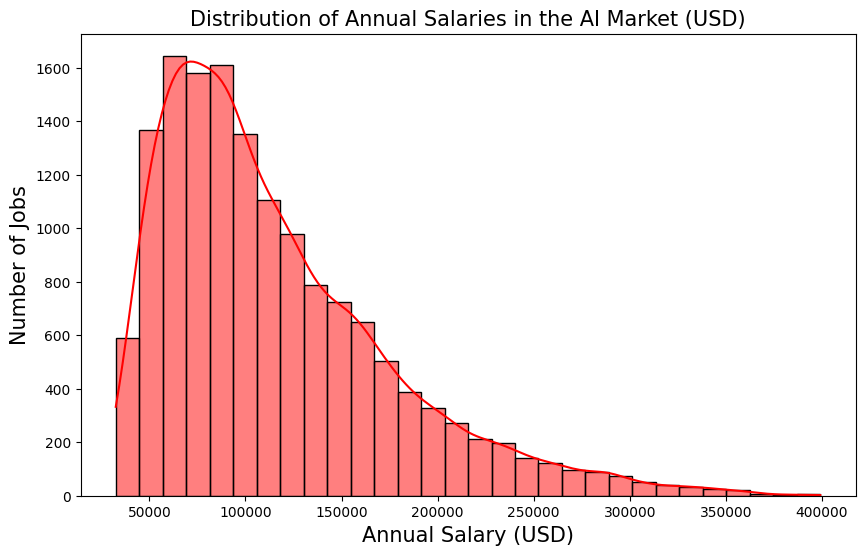

In [32]:
# ============================================================
# 7. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

plt.figure(figsize=(10, 6))
sns.histplot(df['salary_usd'], bins=30, kde=True, color='Red')
plt.title('Distribution of Annual Salaries in the AI Market (USD)', fontsize=15)
plt.xlabel('Annual Salary (USD)', fontsize=15)
plt.ylabel('Number of Jobs', fontsize=15)
plt.show()

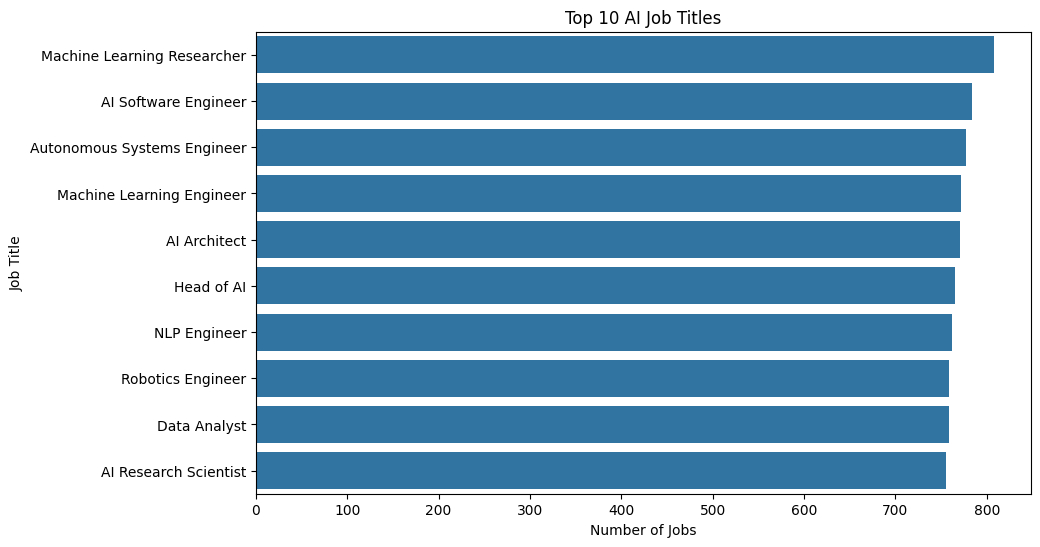

In [33]:
top_jobs = df["job_title"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_jobs.values, y=top_jobs.index)

plt.title("Top 10 AI Job Titles")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")

plt.show()

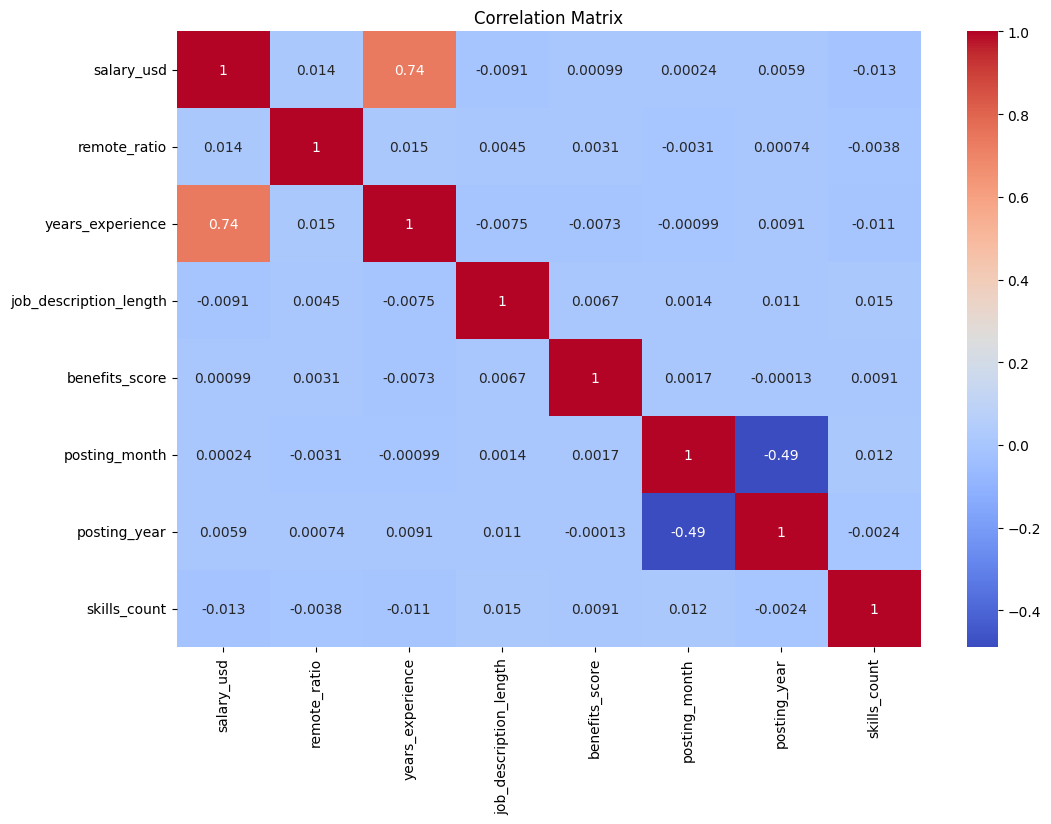

In [35]:
# ============================================================
# 8. CORRELATION HEATMAP
# ============================================================

numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()



#Couleur rouge → corrélation positive (quand une variable augmente, l’autre aussi).
#Couleur bleue → corrélation négative (quand une variable augmente, l’autre diminue).
#Valeur proche de 0 → pas de relation linéaire claire.



🖼️ Comment lire ton heatmap
Chaque case représente la corrélation entre deux variables :

Couleur rouge → corrélation positive (quand une variable augmente, l’autre aussi).

Couleur bleue → corrélation négative (quand une variable augmente, l’autre diminue).

Valeur proche de 0 → pas de relation linéaire claire.

📊 Ce que ton heatmap montre
salary_usd ↔ years_experience = 0.74  
👉 Plus l’expérience augmente, plus le salaire augmente. C’est une relation forte et logique.

posting_month ↔ posting_year = -0.49  
👉 Relation négative : les mois et années sont naturellement liés mais inversés dans ton encodage. Pas très utile pour la prédiction.

remote_ratio ↔ salary_usd → corrélation faible.
👉 Le fait d’être en télétravail n’a pas un impact direct sur le salaire dans ton dataset.

skills_count ↔ salary_usd → corrélation modérée.
👉 Plus de compétences listées peut être associé à un salaire plus élevé.

In [36]:
# ============================================================
# 9. DEFINE FEATURES & TARGET
# ============================================================

X = df.drop("salary_usd", axis=1)

y = df["salary_usd"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (15000, 16)
Target Shape: (15000,)


In [37]:
# ============================================================
# 10. FEATURE TYPES
# ============================================================

numerical_features = [
    'remote_ratio',
    'years_experience',
    'job_description_length',
    'benefits_score',
    'posting_month',
    'posting_year',
    'skills_count'
]

categorical_features = [
    'job_title',
    'experience_level',
    'employment_type',
    'company_location',
    'company_size',
    'employee_residence',
    'education_required',
    'industry'
]

text_feature = 'required_skills'



In [53]:
# ============================================================
# 11. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numerical_features
        ),

        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),

        (
            'text',
            TfidfVectorizer(max_features=100),
            'required_skills'
        )
    ]
)

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [56]:
# ============================================================
# 12. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (12000, 16)
Test Shape: (3000, 16)


In [59]:
# ============================================================
# 13. CREATE MODEL PIPELINE
# ============================================================

model = Pipeline([

    ('preprocessor', preprocessor),

    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipeline Created Successfully")

Pipeline Created Successfully


In [60]:
# ============================================================
# 14. TRAIN MODEL
# ============================================================

print("Training Model...")

model.fit(X_train, y_train)

print("Training Completed")

Training Model...
Training Completed


In [61]:
# ============================================================
# 15. MAKE PREDICTIONS
# ============================================================

predictions = model.predict(X_test)

print(predictions[:5])

[152014.84  166629.095 136285.915 172683.385  75272.01 ]


In [62]:
# ============================================================
# 16. EVALUATE MODEL
# ============================================================

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\n================ MODEL EVALUATION ================\n")

print("MAE :", mae) #MAE (Mean Absolute Error) Plus il est petit, plus les prédictions sont proches des vraies valeurs.

print("MSE :", mse) #MSE (Mean Squared Error) Moyenne des erreurs au carré.

print("RMSE:", rmse) #RMSE (Root Mean Squared Error) Racine carrée du MSE

print("R2 Score:", r2) #R² (Coefficient de détermination) Valeurs possibles : 1 → prédictions parfaites. 0 → le modèle n’explique rien (équivalent à prédire la moyenne). < 0 → pire qu’un modèle trivial.


================ MODEL EVALUATION ================

MAE : 15143.088478333335
MSE : 448878680.2867176
RMSE: 21186.75719138532
R2 Score: 0.876924737526413


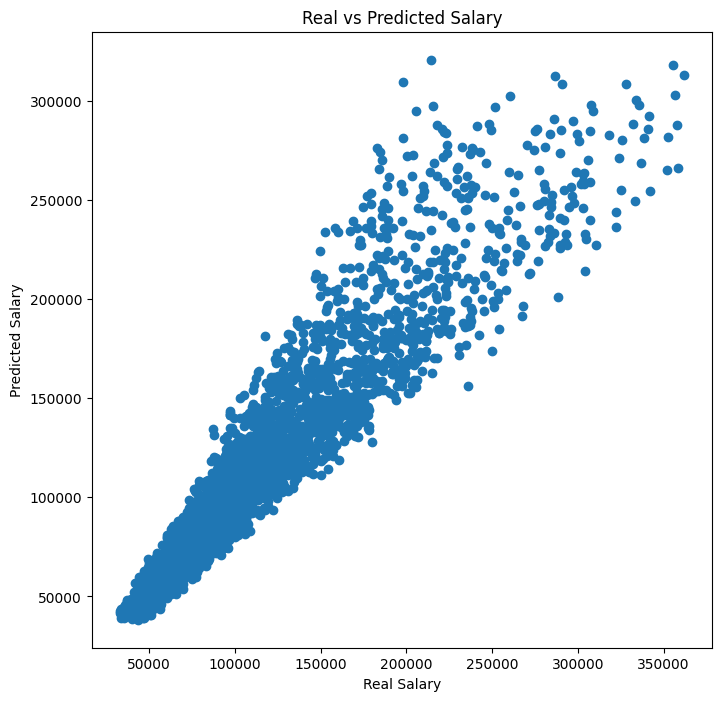

In [63]:
# ============================================================
# 17. PREDICTION VS REAL GRAPH
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(y_test, predictions)

plt.xlabel("Real Salary")

plt.ylabel("Predicted Salary")

plt.title("Real vs Predicted Salary")

plt.show()

In [64]:
# ============================================================
# 18. SAVE MODEL
# ============================================================

joblib.dump(model, "salary_predictor_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [65]:
# ============================================================
# 19. TEST WITH CUSTOM INPUT
# ============================================================

sample_data = pd.DataFrame({

    'job_title': ['Machine Learning Engineer'],

    'experience_level': ['SE'],

    'employment_type': ['FT'],

    'company_location': ['United States'],

    'company_size': ['M'],

    'employee_residence': ['United States'],

    'remote_ratio': [100],

    'required_skills': ['Python, TensorFlow, AWS'],

    'education_required': ['Master'],

    'years_experience': [4],

    'industry': ['Technology'],

    'job_description_length': [1500],

    'benefits_score': [8],

    'posting_month': [5],

    'posting_year': [2025],

    'skills_count': [3]
})

prediction = model.predict(sample_data)

print("\n================ SAMPLE PREDICTION ================\n")

print("Predicted Salary USD:", prediction[0])


================ SAMPLE PREDICTION ================

Predicted Salary USD: 117192.55


In [66]:
# ============================================================
# 20. LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load("salary_predictor_model.pkl")

print("Saved Model Loaded Successfully")

Saved Model Loaded Successfully


In [48]:
# ============================================================
# END PROJECT
# ============================================================